# CoreMark Performance Analysis - 15 Hour Run

This notebook analyzes CoreMark benchmark results collected over 15 hours across different AWS instance types.

## 1. Import Libraries and Setup

In [45]:
import json
import os
import csv
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

## 2. Define Data Extraction Functions

In [46]:
def extract_cpu_info(json_file_path):
    """Extract CPU model information from perfkitbenchmarker_results.json"""
    try:
        with open(json_file_path, 'r') as f:
            lines = f.readlines()
        
        cpu_model = "Not found"
        
        for line in lines:
            if not line.strip():
                continue
            try:
                item = json.loads(line)
                
                if item.get('metric') == 'lscpu':
                    labels = item.get('labels', '')
                    for label in labels.split('|,|'):
                        if 'Model name:' in label:
                            cpu_model = label.split('Model name:')[1].strip('|')
                            break
                        elif 'model name:' in label:
                            cpu_model = label.split('model name:')[1].strip('|')
                            break
                
                if cpu_model == "Not found":
                    labels = item.get('labels', '')
                    for label in labels.split('|,|'):
                        if 'cpu_model:' in label:
                            cpu_model = label.split('cpu_model:')[1].strip('|')
                            break
            except json.JSONDecodeError:
                continue
                    
        return cpu_model
    except Exception as e:
        return f"Error: {str(e)}"

def extract_coremark_scores(json_file_path):
    """Extract all CoreMark scores from perfkitbenchmarker_results.json"""
    scores = []
    try:
        with open(json_file_path, 'r') as f:
            lines = f.readlines()
        
        for line in lines:
            if not line.strip():
                continue
            try:
                item = json.loads(line)
                
                if item.get('metric') == 'Coremark Score':
                    score = item.get('value', 0)
                    if score > 0:
                        scores.append(score)
            except json.JSONDecodeError:
                continue
                    
        return scores
    except Exception as e:
        return []

## 3. Extract Data from All Runs

In [47]:
# Current directory is runs_15h
base_dir = Path("/Users/taeyoon/Desktop/KubeCaps/PerfKitBenchmarker/runs_15h")
results = []

# Get all directories that match the pattern
for dir_name in os.listdir(base_dir):
    dir_path = base_dir / dir_name
    if not dir_path.is_dir() or dir_name == 'extract_data.py':
        continue
    
    # Parse directory name for instance type and timestamp
    # Format: instanceTypeYYYYMMDDHHMMSS
    # Examples: c7ilarge20250821110000, t3micro20250821120000
    
    # Find where the date starts (first digit after instance type)
    date_start_idx = 0
    for i, char in enumerate(dir_name):
        if char.isdigit() and len(dir_name[i:]) >= 14:  # Ensure we have a full timestamp
            if dir_name[i:i+14].isdigit():  # Check if next 14 chars are all digits
                date_start_idx = i
                break
    
    if date_start_idx == 0:
        continue
    
    instance_type = dir_name[:date_start_idx]
    timestamp_str = dir_name[date_start_idx:date_start_idx+14]
    
    try:
        # Parse timestamp
        timestamp = datetime.strptime(timestamp_str, "%Y%m%d%H%M%S")
        hour = timestamp.hour
    except ValueError:
        continue
    
    json_file = dir_path / "perfkitbenchmarker_results.json"
    if json_file.exists():
        cpu_model = extract_cpu_info(json_file)
        coremark_scores = extract_coremark_scores(json_file)
        avg_coremark = sum(coremark_scores) / len(coremark_scores) if coremark_scores else 0
        
        result = {
            'instance_type': instance_type,
            'timestamp': timestamp,
            'hour': hour,
            'cpu_model': cpu_model,
            'avg_coremark': round(avg_coremark, 2),
            'num_scores': len(coremark_scores)
        }
        
        # Add individual scores
        for i in range(5):
            if i < len(coremark_scores):
                result[f'score_{i+1}'] = round(coremark_scores[i], 2)
            else:
                result[f'score_{i+1}'] = None
        
        results.append(result)
        print(f"Processed: {instance_type} at {timestamp.strftime('%Y-%m-%d %H:%M')} - Avg CoreMark: {avg_coremark:,.2f}")

# Create DataFrame
df = pd.DataFrame(results)
df = df.sort_values(['instance_type', 'timestamp'])
print(f"\nTotal records processed: {len(df)}")
print(f"Instance types found: {df['instance_type'].unique()}")

Processed: m7ilarge at 2025-08-21 11:00 - Avg CoreMark: 28,881.27
Processed: t3micro at 2025-08-21 18:00 - Avg CoreMark: 21,531.36
Processed: t3micro at 2025-08-21 19:00 - Avg CoreMark: 21,378.65
Processed: m7ilarge at 2025-08-21 12:00 - Avg CoreMark: 30,809.42
Processed: r7ilarge at 2025-08-22 00:00 - Avg CoreMark: 27,722.60
Processed: r7ilarge at 2025-08-22 01:00 - Avg CoreMark: 29,317.33
Processed: m7ilarge at 2025-08-21 13:00 - Avg CoreMark: 28,634.50
Processed: m7ilarge at 2025-08-21 17:00 - Avg CoreMark: 30,943.68
Processed: t3micro at 2025-08-21 22:00 - Avg CoreMark: 21,271.12
Processed: i7ilarge at 2025-08-22 00:00 - Avg CoreMark: 31,676.14
Processed: i7ilarge at 2025-08-22 01:00 - Avg CoreMark: 34,322.31
Processed: t3micro at 2025-08-21 23:00 - Avg CoreMark: 21,511.70
Processed: m7ilarge at 2025-08-21 16:00 - Avg CoreMark: 28,042.80
Processed: c7ilarge at 2025-08-22 00:00 - Avg CoreMark: 30,736.70
Processed: m7ilarge at 2025-08-21 14:00 - Avg CoreMark: 29,978.95
Processed: t3m

## 4. Data Overview and Statistics

In [48]:
# Display data summary
print("Data Shape:", df.shape)
print("\nColumn Types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Data Shape: (75, 11)

Column Types:
instance_type            object
timestamp        datetime64[ns]
hour                      int64
cpu_model                object
avg_coremark            float64
num_scores                int64
score_1                 float64
score_2                 float64
score_3                 float64
score_4                 float64
score_5                 float64
dtype: object

First 5 rows:


,instance_type,timestamp,hour,cpu_model,avg_coremark,num_scores,score_1,score_2,score_3,score_4,score_5
21,c7ilarge,2025-08-21 11:00:00,11,Intel(R) Xeon(R) Platinum 8488C,28026.82,5,28026.91,27941.55,28057.57,28060.72,28047.34
26,c7ilarge,2025-08-21 12:00:00,12,Intel(R) Xeon(R) Platinum 8488C,27600.45,5,27706.20,27693.93,27423.56,27483.85,27694.69
25,c7ilarge,2025-08-21 13:00:00,13,Intel(R) Xeon(R) Platinum 8488C,28001.00,5,27909.57,27941.55,28016.70,28067.81,28069.39
39,c7ilarge,2025-08-21 14:00:00,14,Intel(R) Xeon(R) Platinum 8488C,27514.02,5,27467.25,27552.00,27577.84,27471.77,27501.24
36,c7ilarge,2025-08-21 15:00:00,15,Intel(R) Xeon(R) Platinum 8488C,30970.71,5,30922.42,30978.93,30964.55,30996.22,30991.42


In [49]:
# Summary statistics by instance type
summary_stats = df.groupby('instance_type')['avg_coremark'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std', 'std'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('CV%', lambda x: (x.std() / x.mean() * 100) if x.mean() > 0 else 0)
]).round(2)

summary_stats = summary_stats.sort_values('Mean', ascending=False)
print("\nCoreMark Statistics by Instance Type:")
summary_stats


CoreMark Statistics by Instance Type:


,Count,Mean,Median,Std,Min,Max,CV%
instance_type,,,,,,,
i7ilarge,15,31227.94,30785.16,1528.96,28309.06,34322.31,4.90
m7ilarge,15,29839.35,29842.21,1574.62,27683.38,32123.30,5.28
r7ilarge,15,29054.54,28667.49,1478.24,27435.75,31643.80,5.09
c7ilarge,15,28921.02,28026.82,1392.77,27514.02,30970.71,4.82
t3micro,15,21362.90,21384.47,202.53,20820.29,21646.26,0.95


## 5. Main Visualization: CoreMark Performance Over Time

## 7. Performance Variability Analysis (Standard Deviation & Box Plot)

In [50]:
# Calculate deviation from mean for each instance type
print("="*70)
print("Performance Variability Analysis")
print("="*70)

# Create a new dataframe with deviation calculations
deviation_data = []

for instance in instance_types:
    instance_data = df[df['instance_type'] == instance]['avg_coremark']
    mean_score = instance_data.mean()
    std_score = instance_data.std()
    
    # Calculate percentage deviation from mean for each measurement
    for score in instance_data:
        percent_deviation = abs((score - mean_score) / mean_score * 100)
        deviation_data.append({
            'instance_type': instance,
            'score': score,
            'mean': mean_score,
            'percent_deviation': percent_deviation
        })
    
    # Print statistics for each instance type
    cv_percent = (std_score / mean_score * 100)
    print(f"\n{instance}:")
    print(f"  Average CoreMark: {mean_score:,.2f}")
    print(f"  Standard Deviation: {std_score:,.2f}")
    print(f"  Coefficient of Variation: {cv_percent:.2f}%")
    print(f"  Range: {instance_data.min():,.2f} - {instance_data.max():,.2f}")
    print(f"  Max deviation from mean: {((instance_data.max() - mean_score) / mean_score * 100):.2f}%")
    print(f"  Min deviation from mean: {((mean_score - instance_data.min()) / mean_score * 100):.2f}%")

deviation_df = pd.DataFrame(deviation_data)

print("\n" + "="*70)

Performance Variability Analysis

c7ilarge:
  Average CoreMark: 28,921.02
  Standard Deviation: 1,392.77
  Coefficient of Variation: 4.82%
  Range: 27,514.02 - 30,970.71
  Max deviation from mean: 7.09%
  Min deviation from mean: 4.86%

i7ilarge:
  Average CoreMark: 31,227.94
  Standard Deviation: 1,528.96
  Coefficient of Variation: 4.90%
  Range: 28,309.06 - 34,322.31
  Max deviation from mean: 9.91%
  Min deviation from mean: 9.35%

m7ilarge:
  Average CoreMark: 29,839.35
  Standard Deviation: 1,574.62
  Coefficient of Variation: 5.28%
  Range: 27,683.38 - 32,123.30
  Max deviation from mean: 7.65%
  Min deviation from mean: 7.23%

r7ilarge:
  Average CoreMark: 29,054.54
  Standard Deviation: 1,478.24
  Coefficient of Variation: 5.09%
  Range: 27,435.75 - 31,643.80
  Max deviation from mean: 8.91%
  Min deviation from mean: 5.57%

t3micro:
  Average CoreMark: 21,362.90
  Standard Deviation: 202.53
  Coefficient of Variation: 0.95%
  Range: 20,820.29 - 21,646.26
  Max deviation from 

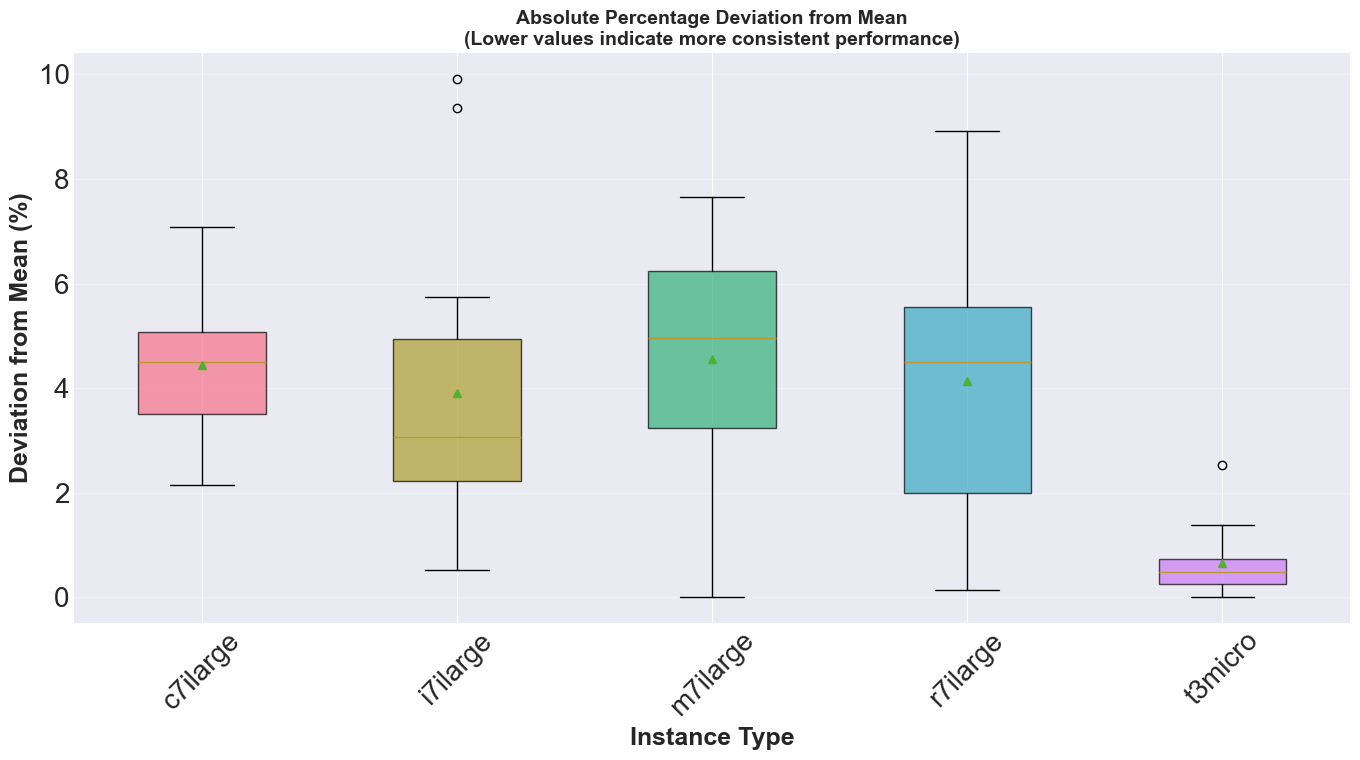


Summary of Percentage Deviations from Mean:


In [59]:
# Box plot showing percentage deviation from mean for each instance type
plt.rcParams['font.size'] = 20
fig, ax = plt.subplots(figsize=(14, 8))


# Prepare data for box plot - percentage deviation from mean
box_data = []
labels = []
for instance in instance_types:
    instance_deviations = deviation_df[deviation_df['instance_type'] == instance]['percent_deviation'].values
    box_data.append(instance_deviations)
    labels.append(instance)

bp = ax.boxplot(box_data, labels=labels, patch_artist=True, showmeans=True)

# Color the boxes
colors_box = sns.color_palette("husl", len(instance_types))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Customize the plot
ax.set_xlabel('Instance Type', fontsize=18, fontweight='bold')
ax.set_ylabel('Deviation from Mean (%)', fontsize=18, fontweight='bold')
ax.set_title('Absolute Percentage Deviation from Mean\n(Lower values indicate more consistent performance)', 
             fontsize=14, fontweight='bold')

# Add horizontal line at specific percentages for reference

ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print summary statistics for the deviations
print("\nSummary of Percentage Deviations from Mean:")

In [52]:
# Create a summary table of deviation statistics
deviation_summary = deviation_df.groupby('instance_type')['percent_deviation'].agg([
    ('Mean Deviation %', 'mean'),
    ('Median Deviation %', 'median'),
    ('Max Deviation %', 'max'),
    ('75th Percentile %', lambda x: x.quantile(0.75)),
    ('25th Percentile %', lambda x: x.quantile(0.25))
]).round(2)

deviation_summary = deviation_summary.sort_values('Mean Deviation %')
print(deviation_summary)
print("\nMost Stable Instance (lowest mean deviation):", deviation_summary.index[0])
print("Least Stable Instance (highest mean deviation):", deviation_summary.index[-1])

               Mean Deviation %  Median Deviation %  Max Deviation %  \
instance_type                                                          
t3micro                    0.65                0.49             2.54   
i7ilarge                   3.91                3.06             9.91   
r7ilarge                   4.13                4.50             8.91   
c7ilarge                   4.44                4.50             7.09   
m7ilarge                   4.55                4.97             7.65   

               75th Percentile %  25th Percentile %  
instance_type                                        
t3micro                     0.74               0.27  
i7ilarge                    4.93               2.22  
r7ilarge                    5.54               1.99  
c7ilarge                    5.07               3.50  
m7ilarge                    6.25               3.23  

Most Stable Instance (lowest mean deviation): t3micro
Least Stable Instance (highest mean deviation): m7ilarge


## 8. Export Results

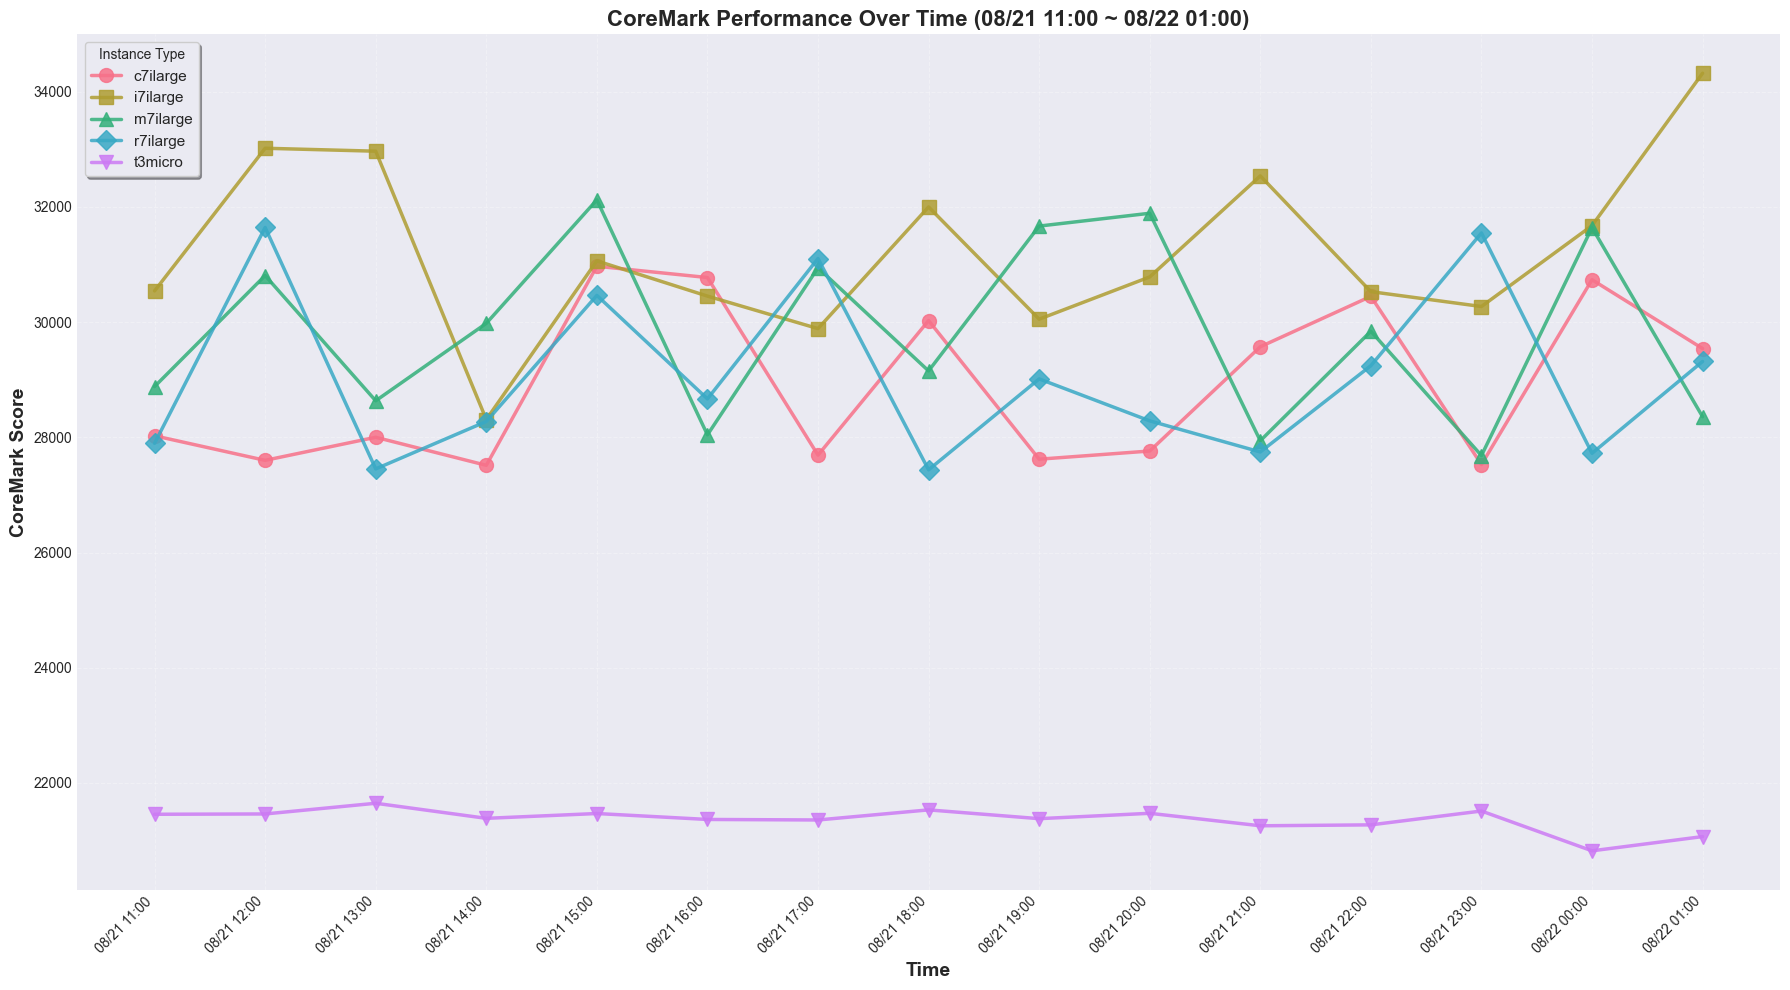

In [53]:
# Line plot showing performance over actual time
fig, ax = plt.subplots(figsize=(18, 10))

instance_types = df['instance_type'].unique()
colors = sns.color_palette("husl", len(instance_types))
markers = ['o', 's', '^', 'D', 'v']

for idx, instance in enumerate(instance_types):
    instance_data = df[df['instance_type'] == instance].sort_values('timestamp')
    ax.plot(instance_data['timestamp'], 
            instance_data['avg_coremark'],
            marker=markers[idx % len(markers)],
            label=instance,
            linewidth=2.5,
            markersize=10,
            alpha=0.85,
            color=colors[idx])

ax.set_xlabel('Time', fontsize=14, fontweight='bold')
ax.set_ylabel('CoreMark Score', fontsize=14, fontweight='bold')
ax.set_title('CoreMark Performance Over Time (08/21 11:00 ~ 08/22 01:00)', fontsize=16, fontweight='bold')

# Format x-axis to show date and time
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.xticks(rotation=45, ha='right')

ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='best', title='Instance Type', frameon=True, fancybox=True, shadow=True, fontsize=11)

plt.tight_layout()
plt.show()

## 6. Cumulative Average Performance Over Time

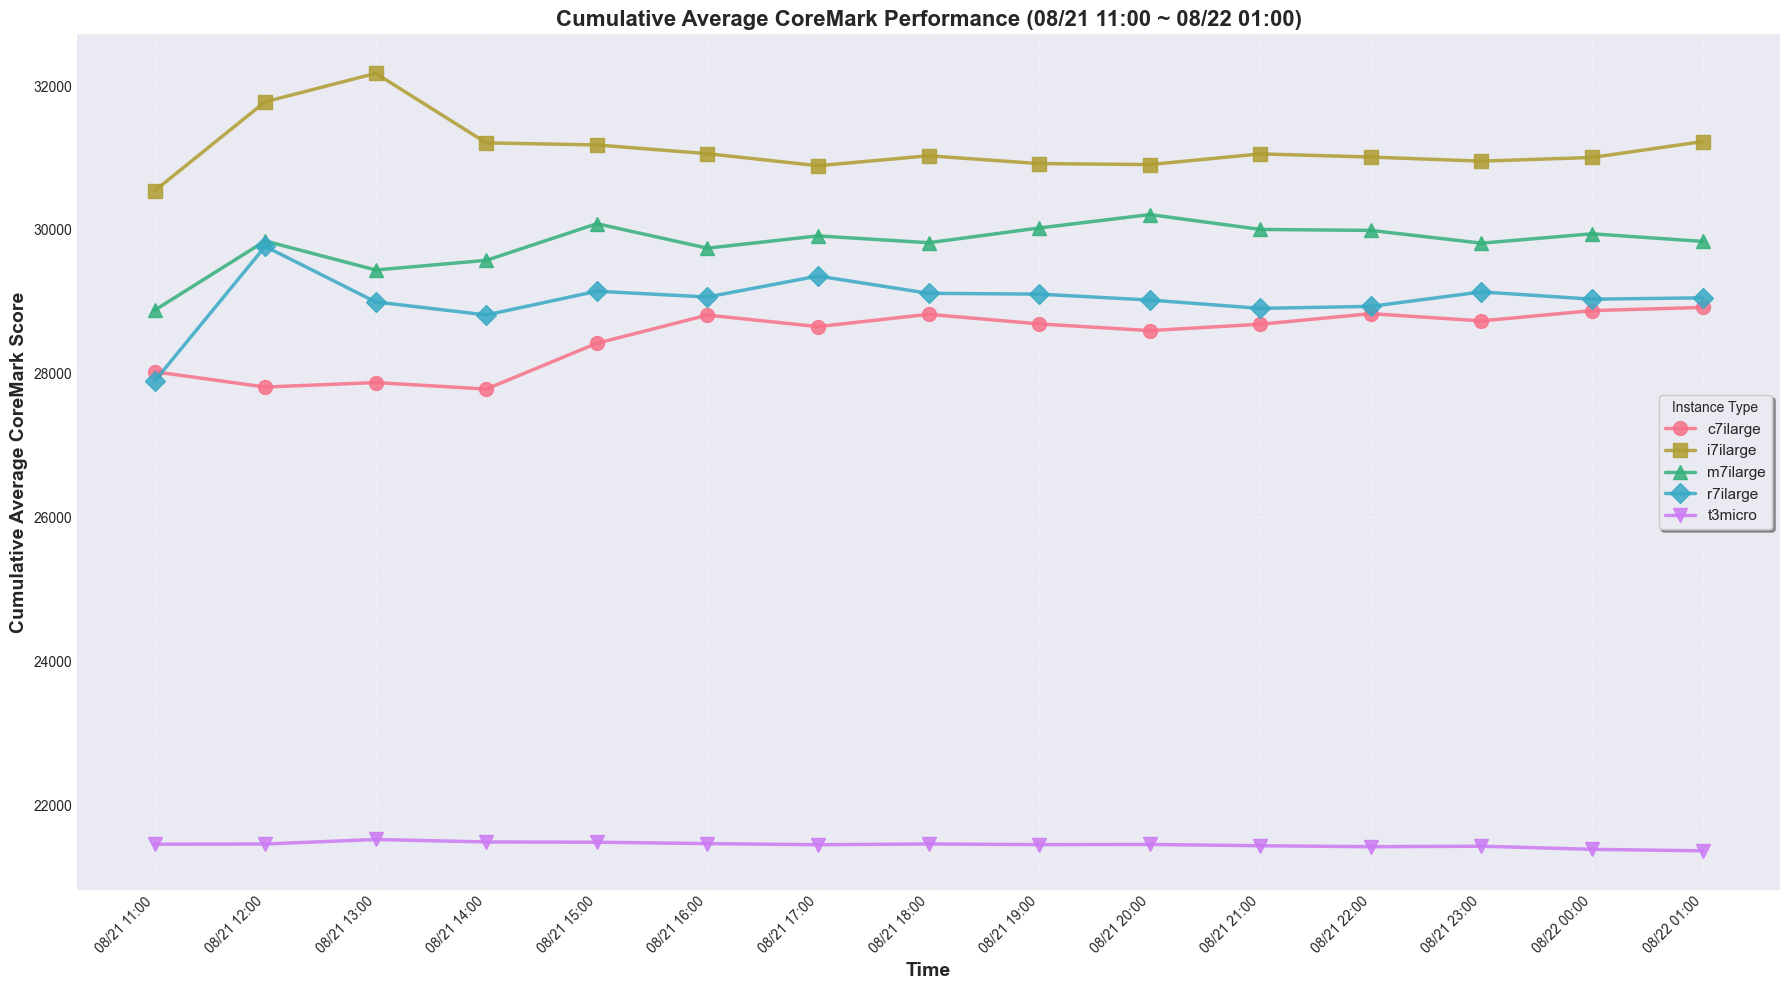


Final Cumulative Averages:
  c7ilarge: 28,921.02
  i7ilarge: 31,227.94
  m7ilarge: 29,839.35
  r7ilarge: 29,054.54
  t3micro: 21,362.90


In [54]:
# Calculate cumulative average for each instance type
fig, ax = plt.subplots(figsize=(18, 10))

instance_types = df['instance_type'].unique()
colors = sns.color_palette("husl", len(instance_types))
markers = ['o', 's', '^', 'D', 'v']

for idx, instance in enumerate(instance_types):
    instance_data = df[df['instance_type'] == instance].sort_values('timestamp').copy()
    
    # Calculate cumulative average
    instance_data['cumulative_avg'] = instance_data['avg_coremark'].expanding().mean()
    
    ax.plot(instance_data['timestamp'], 
            instance_data['cumulative_avg'],
            marker=markers[idx % len(markers)],
            label=instance,
            linewidth=2.5,
            markersize=10,
            alpha=0.85,
            color=colors[idx])

ax.set_xlabel('Time', fontsize=14, fontweight='bold')
ax.set_ylabel('Cumulative Average CoreMark Score', fontsize=14, fontweight='bold')
ax.set_title('Cumulative Average CoreMark Performance (08/21 11:00 ~ 08/22 01:00)', fontsize=16, fontweight='bold')

# Format x-axis to show date and time
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.xticks(rotation=45, ha='right')

ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='best', title='Instance Type', frameon=True, fancybox=True, shadow=True, fontsize=11)

plt.tight_layout()
plt.show()

# Print final cumulative averages
print("\nFinal Cumulative Averages:")
for instance in instance_types:
    instance_data = df[df['instance_type'] == instance].sort_values('timestamp')
    final_avg = instance_data['avg_coremark'].mean()
    print(f"  {instance}: {final_avg:,.2f}")

## 7. Export Results

In [55]:
# Save processed data to CSV
output_file = base_dir / "coremark_analysis_results.csv"
df.to_csv(output_file, index=False)
print(f"Results saved to: {output_file}")

# Save summary statistics
summary_file = base_dir / "coremark_summary_stats.csv"
summary_stats.to_csv(summary_file)
print(f"Summary statistics saved to: {summary_file}")

# Display final summary
print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print(f"Total measurements analyzed: {len(df)}")
print(f"Instance types tested: {len(instance_types)}")
print(f"Time range: {df['timestamp'].min().strftime('%m/%d %H:%M')} - {df['timestamp'].max().strftime('%m/%d %H:%M')}")
print(f"\nTop 3 performers (by average CoreMark):")
top_performers = summary_stats.nlargest(3, 'Mean')[['Mean', 'CV%']]
for idx, (instance, row) in enumerate(top_performers.iterrows(), 1):
    print(f"  {idx}. {instance}: {row['Mean']:.2f} (CV: {row['CV%']:.2f}%)")

print(f"\nMost stable performer (lowest CV%):")
most_stable = summary_stats.nsmallest(1, 'CV%')[['Mean', 'CV%']]
for instance, row in most_stable.iterrows():
    print(f"  {instance}: {row['Mean']:.2f} (CV: {row['CV%']:.2f}%)")

Results saved to: /Users/taeyoon/Desktop/KubeCaps/PerfKitBenchmarker/runs_15h/coremark_analysis_results.csv
Summary statistics saved to: /Users/taeyoon/Desktop/KubeCaps/PerfKitBenchmarker/runs_15h/coremark_summary_stats.csv

ANALYSIS COMPLETE
Total measurements analyzed: 75
Instance types tested: 5
Time range: 08/21 11:00 - 08/22 01:00

Top 3 performers (by average CoreMark):
  1. i7ilarge: 31227.94 (CV: 4.90%)
  2. m7ilarge: 29839.35 (CV: 5.28%)
  3. r7ilarge: 29054.54 (CV: 5.09%)

Most stable performer (lowest CV%):
  t3micro: 21362.90 (CV: 0.95%)
